In [3]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

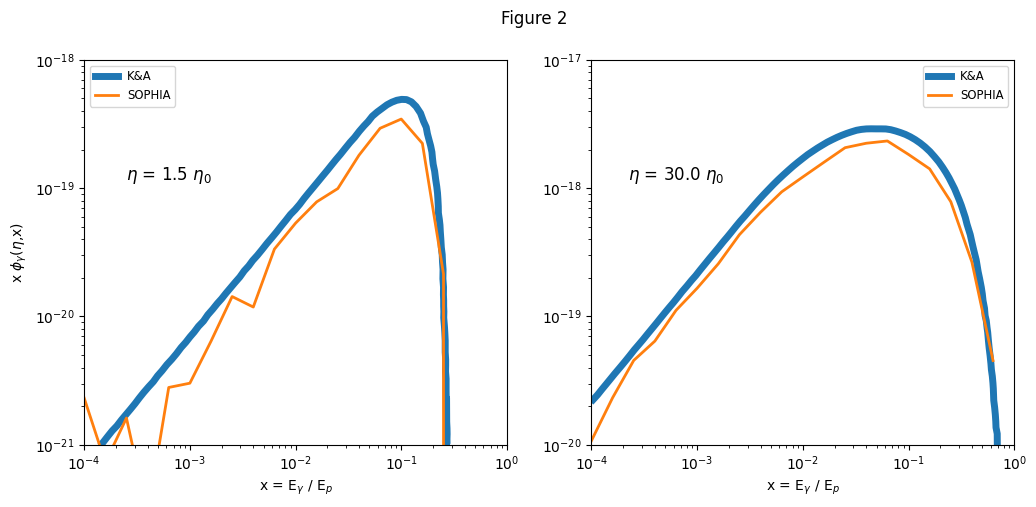

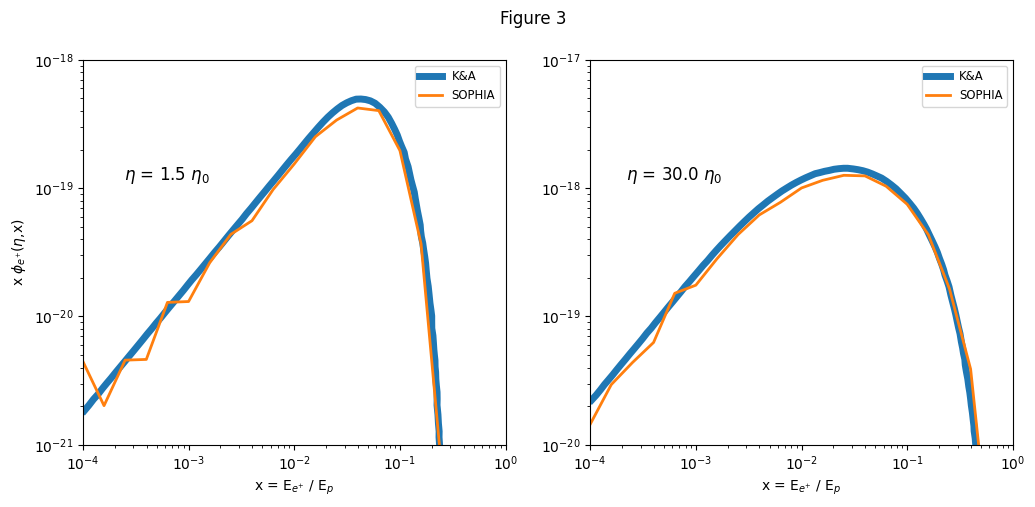

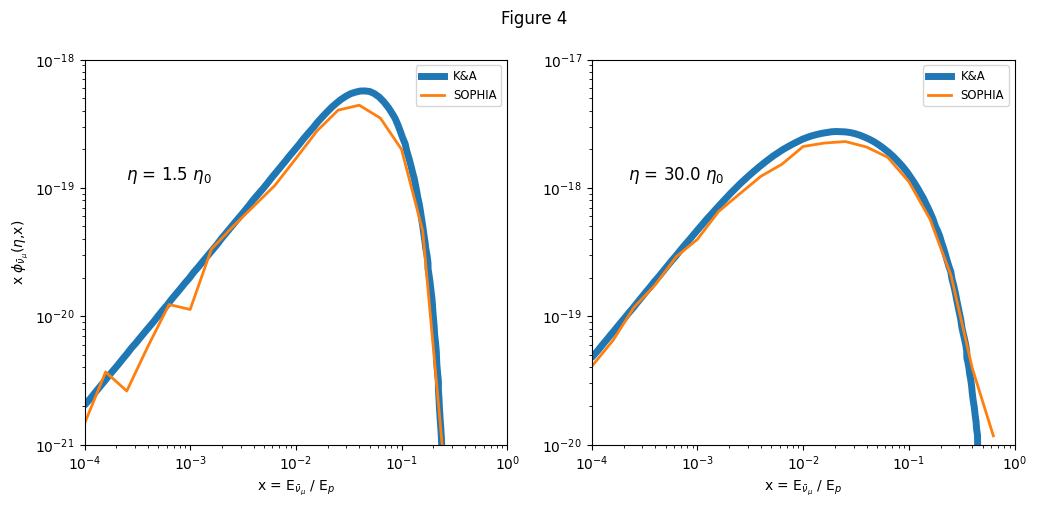

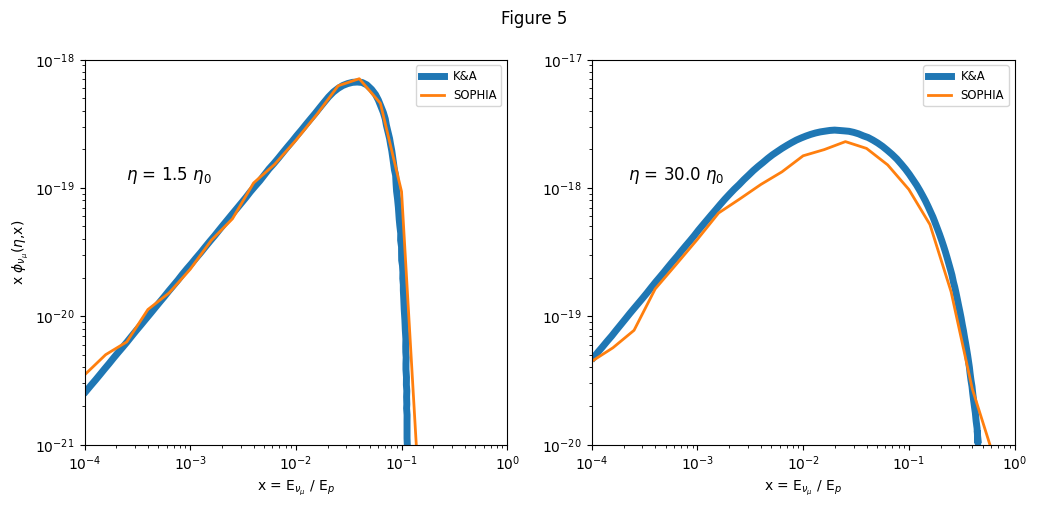

In [36]:
"""
[KelnerAharonian2008] figure 2, 3, 4, 5
"""

def xphi_plot(fig_number):

    if fig_number == "2":
        particle = "gamma"
        label = r"\gamma"
    if fig_number == "3":
        particle = "positron"
        label = r"e^{+}"
    if fig_number == "4":
        particle = "muon_antineutrino"
        label = r"\bar{\nu}_{\mu}"
    if fig_number == "5":
        particle = "muon_neutrino"
        label = r"\nu_{\mu}"

    x = np.logspace(-5,1,100)

    fig, ax = plt.subplots(1,2,figsize = (12, 5))

    fig.suptitle(f"Figure {fig_number}")

    param_tab = ["1.5","30"]

    i = 0
    for parameter in param_tab:
        interp_file = (
            f"./kelner_aharonian_2008/fig{fig_number}_values/{particle}_{parameter}eta0.txt"
        )

        x_i, spectrum = np.genfromtxt(
            interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
        )

        x_i = np.power(10,x_i)
        spectrum = np.power(10,spectrum)

        ax[i].loglog(x_i,spectrum,lw=5,label=r"K&A")

        interp_file = (
            f"./kelner_aharonian_2008/fig{fig_number}_values/{particle}_{parameter}eta0_sophia.txt"
        )

        x_i, spectrum = np.genfromtxt(
            interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
        )


        ax[i].loglog(x_i,spectrum,lw=2,label=r"SOPHIA")

        i=i+1


    ax[0].set_xlim(1e-4,1e0)
    ax[0].set_ylim(1e-21,1e-18)

    ax[1].set_xlim(1e-4,1e0)
    ax[1].set_ylim(1e-20,1e-17)

    ax[0].set_xlabel(rf"x = E$_{{{label}}}$ / E$_p$")
    ax[1].set_xlabel(rf"x = E$_{{{label}}}$ / E$_p$")

    ax[0].set_ylabel(rf"x $\phi_{{{label}}}$($\eta$,x)")

    ax[0].text(0.2, 0.7, r"$\eta$ = 1.5 $\eta_{0}$", fontsize=12, horizontalalignment='center', verticalalignment='center', transform=ax[0].transAxes)
    ax[1].text(0.2, 0.7, r"$\eta$ = 30.0 $\eta_{0}$", fontsize=12, horizontalalignment='center', verticalalignment='center', transform=ax[1].transAxes)

    ax[0].legend(fontsize = "small")
    ax[1].legend(fontsize = "small")

for i in range(2,6):
    xphi_plot(str(i))